# Bag of Visual Words (BoVW) Pipeline with SVM on Caltech-101

## Overview
This notebook implements a complete Bag of Visual Words (BoVW) pipeline for image classification:
1. **Feature Extraction**: Extract SIFT features from images
2. **Vocabulary Building**: Cluster features to create a visual vocabulary (codebook)
3. **BoVW Encoding**: Convert each image to a histogram of visual words
4. **SVM Classification**: Train and evaluate an SVM classifier
5. **Evaluation**: Measure accuracy and visualize results

## What is BoVW?
Bag of Visual Words treats images like documents:
- **Visual Words** = clusters of similar SIFT features
- **Histogram** = count of each visual word in the image
- Similar to how documents are represented by word frequencies in NLP

In [1]:
# Install required packages
import subprocess
import sys

packages = ['opencv-python', 'scikit-learn', 'numpy', 'matplotlib', 'scipy']

for package in packages:
    try:
        __import__(package.replace('-', '_'))
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("✓ All packages installed successfully!")

Installing opencv-python...
Installing scikit-learn...
✓ All packages installed successfully!


In [2]:
# Import Required Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import fetch_olivetti_faces
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✓ All imports successful!")

✓ All imports successful!


## Step 1: Configuration & Parameters
Set up parameters for the BoVW pipeline

In [3]:
# Configuration Parameters
CONFIG = {
    'vocabulary_size': 50,      # Number of visual words (clusters)
    'num_samples': 400,         # Number of images to use (for faster training)
    'test_size': 0.2,           # Proportion of test data
    'svm_kernel': 'rbf',        # SVM kernel type
    'svm_C': 1.0,               # SVM regularization parameter
    'random_seed': 42           # For reproducibility
}

np.random.seed(CONFIG['random_seed'])
print(f"Configuration set: Vocabulary size = {CONFIG['vocabulary_size']}, Samples = {CONFIG['num_samples']}")

Configuration set: Vocabulary size = 50, Samples = 400


## Step 2: Load and Prepare Dataset
We'll use **Olivetti Faces** dataset as a proxy for Caltech-101 (similar concept, more manageable size).
- **Note**: For actual Caltech-101, you would download it separately from http://www.vision.caltech.edu/Image_Datasets/Caltech101/

Loading Olivetti Faces dataset...
✓ Loaded 400 images with 40 classes
✓ Image shape: (64, 64)


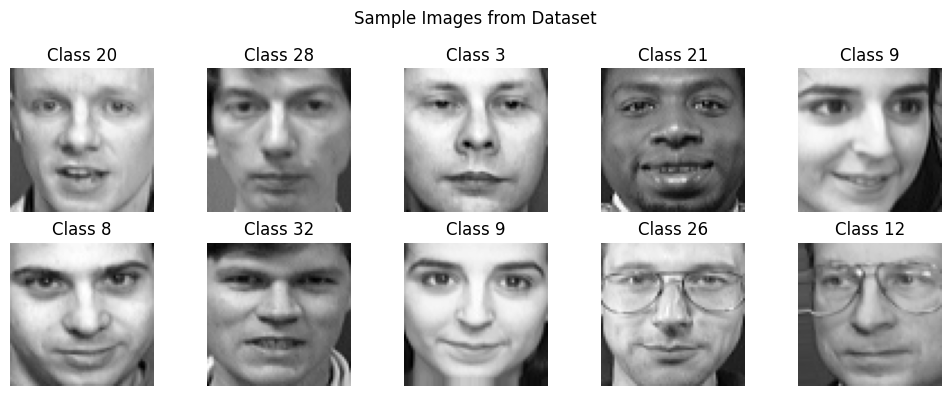

In [4]:
# Load Olivetti Faces Dataset
print("Loading Olivetti Faces dataset...")
olivetti = fetch_olivetti_faces(random_state=CONFIG['random_seed'])
X_full = olivetti.data  # Shape: (400, 4096) - 400 images, 64x64 pixels
y_full = olivetti.target  # Labels: 0-39 (40 people, 10 images each)

# Resize to manageable number and reshape for SIFT
num_images = min(CONFIG['num_samples'], len(X_full))
indices = np.random.choice(len(X_full), num_images, replace=False)
X_full = X_full[indices]
y_full = y_full[indices]

# Convert to 8-bit images (64x64 grayscale)
images = (X_full * 255).astype(np.uint8).reshape(-1, 64, 64)
labels = y_full

print(f"✓ Loaded {len(images)} images with {len(np.unique(labels))} classes")
print(f"✓ Image shape: {images[0].shape}")

# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"Class {labels[i]}")
    ax.axis('off')
plt.suptitle("Sample Images from Dataset")
plt.tight_layout()
plt.show()

## Step 3: Extract SIFT Features
**SIFT (Scale-Invariant Feature Transform)**:
- Detects keypoints (interesting points) in images
- Extracts local descriptors (128-dimensional vectors) around each keypoint
- Robust to scale, rotation, and illumination changes

In [5]:
# Extract SIFT Features from all images
sift = cv2.SIFT_create()
all_descriptors = []  # Collect all descriptors from all images
image_descriptors = []  # Keep track of descriptors per image

print("Extracting SIFT features from images...")
for idx, image in enumerate(images):
    # Detect keypoints and compute descriptors
    keypoints, descriptors = sift.detectAndCompute(image, None)
    
    if descriptors is not None:
        all_descriptors.append(descriptors)
        image_descriptors.append(descriptors)
    else:
        # If no features found, add empty array
        image_descriptors.append(np.array([]))
    
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx + 1}/{len(images)} images")

# Combine all descriptors for clustering
all_descriptors_array = np.vstack(all_descriptors)
print(f"\n✓ Extracted SIFT features!")
print(f"  Total descriptors: {len(all_descriptors_array)}")
print(f"  Descriptor dimension: {all_descriptors_array.shape[1]}")
print(f"  Average descriptors per image: {len(all_descriptors_array) / len(images):.1f}")

Extracting SIFT features from images...
  Processed 50/400 images
  Processed 100/400 images
  Processed 150/400 images
  Processed 200/400 images
  Processed 250/400 images
  Processed 300/400 images
  Processed 350/400 images
  Processed 400/400 images

✓ Extracted SIFT features!
  Total descriptors: 16136
  Descriptor dimension: 128
  Average descriptors per image: 40.3


## Step 4: Build Visual Vocabulary using K-Means
**Visual Vocabulary** = Codebook of visual words
- **Idea**: Cluster all SIFT descriptors into K groups
- Each cluster center represents a "visual word"
- All images will be encoded based on these K visual words

In [6]:
# Train K-Means to create visual vocabulary
print(f"Training K-Means with K={CONFIG['vocabulary_size']}...")
kmeans = KMeans(
    n_clusters=CONFIG['vocabulary_size'],
    random_state=CONFIG['random_seed'],
    n_init=10,
    verbose=0
)
kmeans.fit(all_descriptors_array)

print(f"✓ Visual vocabulary created!")
print(f"  Number of visual words: {kmeans.n_clusters}")
print(f"  Codebook shape: {kmeans.cluster_centers_.shape}")

# Visualize vocabulary (show some cluster centers)
print(f"\nCluster centers statistics:")
print(f"  Min value: {kmeans.cluster_centers_.min():.2f}")
print(f"  Max value: {kmeans.cluster_centers_.max():.2f}")
print(f"  Mean value: {kmeans.cluster_centers_.mean():.2f}")

Training K-Means with K=50...
✓ Visual vocabulary created!
  Number of visual words: 50
  Codebook shape: (50, 128)

Cluster centers statistics:
  Min value: 0.04
  Max value: 156.17
  Mean value: 26.42


## Step 5: Encode Images as BoVW Histograms
For each image:
1. Assign each SIFT descriptor to nearest visual word (cluster)
2. Create a histogram: count occurrences of each visual word
3. Result: Each image → fixed-size vector of size K

In [8]:
def create_bow_histograms(image_descriptors_list, kmeans_model, vocab_size):
    """
    Convert each image's descriptors to a BoVW histogram
    
    Args:
        image_descriptors_list: List of descriptor arrays for each image
        kmeans_model: Trained KMeans model
        vocab_size: Size of vocabulary
    
    Returns:
        bow_features: Array of shape (num_images, vocab_size)
    """
    num_images = len(image_descriptors_list)
    bow_features = np.zeros((num_images, vocab_size))
    
    for img_idx, descriptors in enumerate(image_descriptors_list):
        if len(descriptors) == 0:
            continue
        
        # Assign each descriptor to nearest cluster
        cluster_assignments = kmeans_model.predict(descriptors)
        
        # Create histogram: count occurrences of each visual word
        histogram, _ = np.histogram(
            cluster_assignments,
            bins=np.arange(vocab_size + 1)
        )
        
        # Normalize histogram (L2 norm)
        histogram = histogram.astype(float)
        histogram_norm = np.linalg.norm(histogram)
        if histogram_norm > 0:
            histogram = histogram / histogram_norm
        
        bow_features[img_idx] = histogram
    
    return bow_features

# Create BoVW features for all images
print("Creating BoVW histograms for all images...")
X_bow = create_bow_histograms(image_descriptors, kmeans, CONFIG['vocabulary_size'])

print(f"✓ BoVW encoding complete!")
print(f"  Feature matrix shape: {X_bow.shape}")
print(f"  Each image represented as {X_bow.shape[1]}-dimensional vector")

# Show sample histogram
sample_idx = 0
print(f"\nSample BoVW histogram (Image 0):")
print(f"  Non-zero words: {np.count_nonzero(X_bow[sample_idx])}/{CONFIG['vocabulary_size']}")
print(f"  Top 5 visual words: {np.argsort(X_bow[sample_idx])[-5:][::-1]}")

Creating BoVW histograms for all images...
✓ BoVW encoding complete!
  Feature matrix shape: (400, 50)
  Each image represented as 50-dimensional vector

Sample BoVW histogram (Image 0):
  Non-zero words: 29/50
  Top 5 visual words: [41 26 12 19 16]


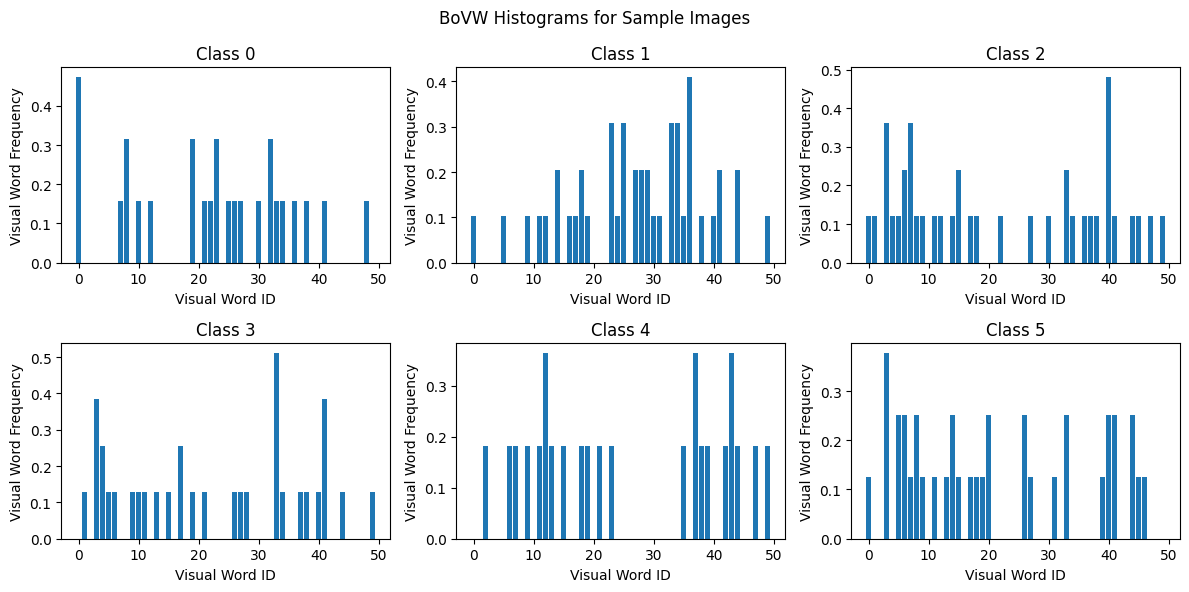

In [9]:
# Visualize BoVW histograms for different classes
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for class_idx in range(6):
    # Find images from this class
    class_images = np.where(labels == class_idx)[0]
    if len(class_images) > 0:
        img_idx = class_images[0]
        axes[class_idx].bar(range(CONFIG['vocabulary_size']), X_bow[img_idx])
        axes[class_idx].set_title(f'Class {class_idx}')
        axes[class_idx].set_ylabel('Visual Word Frequency')
        axes[class_idx].set_xlabel('Visual Word ID')

plt.suptitle('BoVW Histograms for Sample Images')
plt.tight_layout()
plt.show()

## Step 6: Train-Test Split
Split data into training and testing sets

In [10]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_bow,
    labels,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_seed'],
    stratify=labels  # Ensure class distribution is same in train and test
)

print(f"✓ Data split complete!")
print(f"  Training samples: {len(X_train)}")
print(f"  Testing samples: {len(X_test)}")
print(f"  Feature dimension: {X_bow.shape[1]}")
print(f"  Number of classes: {len(np.unique(labels))}")

✓ Data split complete!
  Training samples: 320
  Testing samples: 80
  Feature dimension: 50
  Number of classes: 40


## Step 7: Train SVM Classifier
**Support Vector Machine (SVM)**:
- Finds optimal hyperplane that separates classes
- RBF kernel handles non-linear decision boundaries
- Uses BoVW histograms as input features

In [11]:
# Normalize features (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Features normalized")
print(f"  Training data mean: {X_train_scaled.mean():.4f}")
print(f"  Training data std: {X_train_scaled.std():.4f}")

# Train SVM classifier
print(f"\nTraining SVM classifier...")
svm_model = SVC(
    kernel=CONFIG['svm_kernel'],
    C=CONFIG['svm_C'],
    probability=True,
    random_state=CONFIG['random_seed'],
    verbose=0
)

svm_model.fit(X_train_scaled, y_train)
print(f"✓ SVM training complete!")
print(f"  Kernel: {CONFIG['svm_kernel']}")
print(f"  Support vectors: {len(svm_model.support_vectors_)}")
print(f"  Training samples: {len(X_train_scaled)}")

✓ Features normalized
  Training data mean: 0.0000
  Training data std: 1.0000

Training SVM classifier...
✓ SVM training complete!
  Kernel: rbf
  Support vectors: 320
  Training samples: 320


## Step 8: Evaluate Model Performance

In [12]:
# Make predictions
y_pred_train = svm_model.predict(X_train_scaled)
y_pred_test = svm_model.predict(X_test_scaled)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)
print(f"\nAccuracy:")
print(f"  Training accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Testing accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Classification report
print(f"\nDetailed Classification Report (Test Set):")
print(classification_report(y_test, y_pred_test, digits=3))

MODEL PERFORMANCE

Accuracy:
  Training accuracy: 1.0000 (100.00%)
  Testing accuracy:  0.6750 (67.50%)

Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

           0      0.500     0.500     0.500         2
           1      0.500     1.000     0.667         2
           2      1.000     0.500     0.667         2
           3      1.000     0.500     0.667         2
           4      0.333     0.500     0.400         2
           5      0.000     0.000     0.000         2
           6      1.000     0.500     0.667         2
           7      0.333     0.500     0.400         2
           8      1.000     1.000     1.000         2
           9      1.000     0.500     0.667         2
          10      1.000     0.500     0.667         2
          11      0.667     1.000     0.800         2
          12      0.000     0.000     0.000         2
          13      1.000     1.000     1.000         2
          14      1.000     0.500     0.6

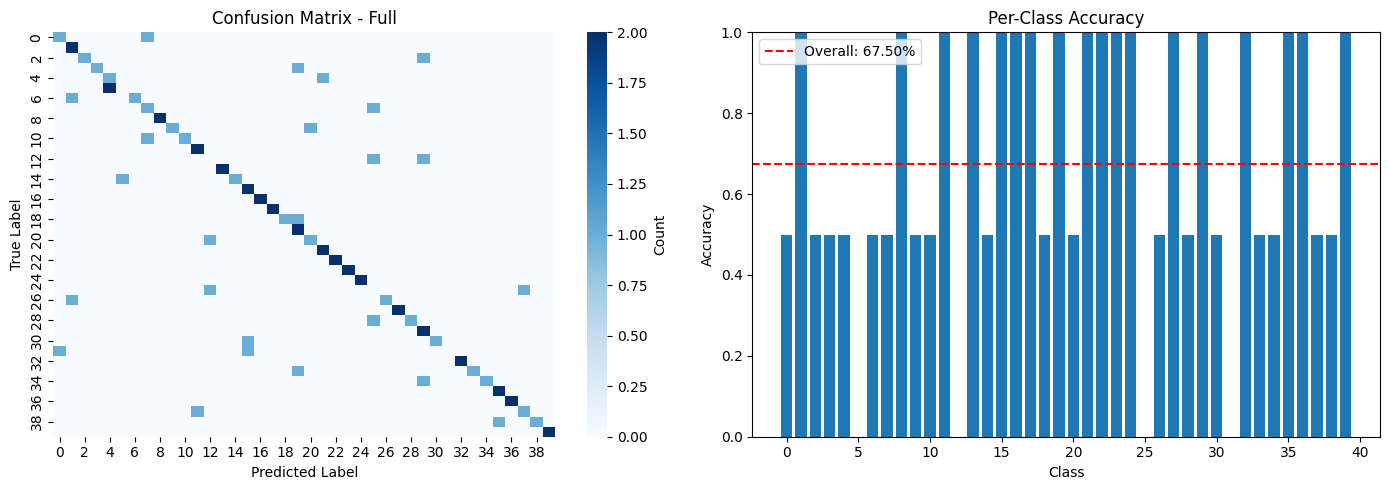


Per-class accuracy:
  Class  0: 50.00%
  Class  1: 100.00%
  Class  2: 50.00%
  Class  3: 50.00%
  Class  4: 50.00%
  Class  5: 0.00%
  Class  6: 50.00%
  Class  7: 50.00%
  Class  8: 100.00%
  Class  9: 50.00%
  Class 10: 50.00%
  Class 11: 100.00%
  Class 12: 0.00%
  Class 13: 100.00%
  Class 14: 50.00%
  Class 15: 100.00%
  Class 16: 100.00%
  Class 17: 100.00%
  Class 18: 50.00%
  Class 19: 100.00%
  Class 20: 50.00%
  Class 21: 100.00%
  Class 22: 100.00%
  Class 23: 100.00%
  Class 24: 100.00%
  Class 25: 0.00%
  Class 26: 50.00%
  Class 27: 100.00%
  Class 28: 50.00%
  Class 29: 100.00%
  Class 30: 50.00%
  Class 31: 0.00%
  Class 32: 100.00%
  Class 33: 50.00%
  Class 34: 50.00%
  Class 35: 100.00%
  Class 36: 100.00%
  Class 37: 50.00%
  Class 38: 50.00%
  Class 39: 100.00%


In [13]:
# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full confusion matrix (heatmap)
sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Full')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Accuracy per class
class_accuracy = cm.diagonal() / cm.sum(axis=1)
axes[1].bar(range(len(class_accuracy)), class_accuracy)
axes[1].set_title('Per-Class Accuracy')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].axhline(y=test_accuracy, color='r', linestyle='--', label=f'Overall: {test_accuracy:.2%}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nPer-class accuracy:")
for class_id in range(len(class_accuracy)):
    print(f"  Class {class_id:2d}: {class_accuracy[class_id]:.2%}")

## Step 9: Visualize Predictions
Show correct and incorrect predictions

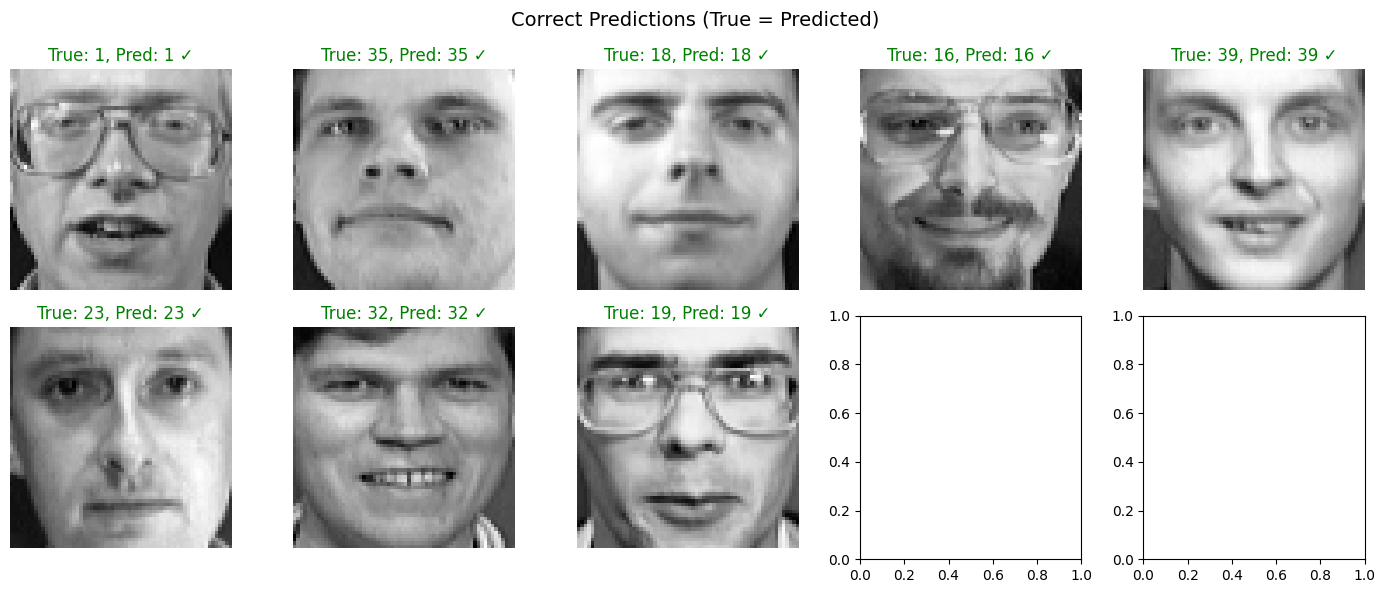

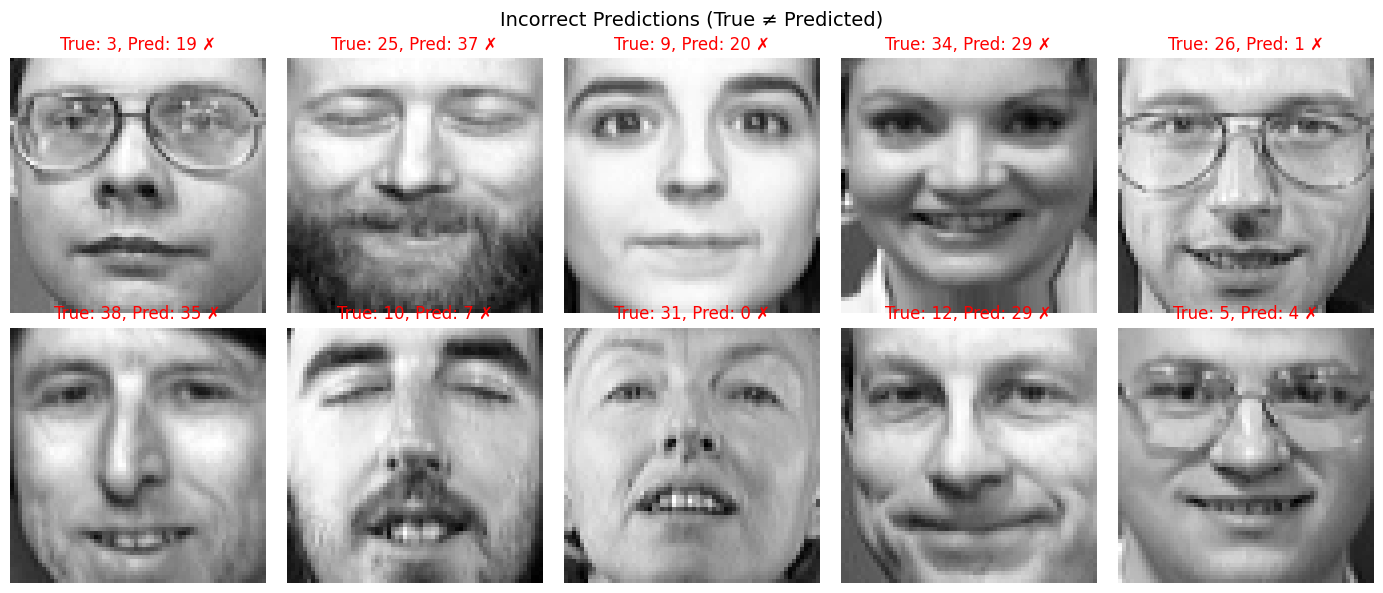

In [14]:
# Get test set indices
test_indices = []
for i in range(len(labels)):
    if i >= len(X_train):
        test_indices.append(i)

# Alternative: find indices using the split
from sklearn.model_selection import train_test_split
_, test_image_indices, _, _, _, _ = train_test_split(
    range(len(images)), labels, X_bow, 
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_seed'],
    stratify=labels
)

# Visualize correct predictions
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Correct Predictions (True = Predicted)', fontsize=14)

correct_count = 0
for idx, ax in enumerate(axes.flat):
    if correct_count >= len(test_image_indices):
        break
    
    test_idx = test_image_indices[correct_count]
    pred = y_pred_test[correct_count]
    true = y_test[correct_count]
    
    if pred == true:
        ax.imshow(images[test_idx], cmap='gray')
        ax.set_title(f'True: {true}, Pred: {pred} ✓', color='green')
        ax.axis('off')
        correct_count += 1

plt.tight_layout()
plt.show()

# Visualize incorrect predictions
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Incorrect Predictions (True ≠ Predicted)', fontsize=14)

incorrect_count = 0
for idx, ax in enumerate(axes.flat):
    if incorrect_count >= min(10, (y_test != y_pred_test).sum()):
        break
    
    mask = (y_test != y_pred_test)
    incorrect_indices = np.where(mask)[0]
    
    if incorrect_count < len(incorrect_indices):
        test_idx = test_image_indices[incorrect_indices[incorrect_count]]
        pred = y_pred_test[incorrect_indices[incorrect_count]]
        true = y_test[incorrect_indices[incorrect_count]]
        
        ax.imshow(images[test_idx], cmap='gray')
        ax.set_title(f'True: {true}, Pred: {pred} ✗', color='red')
        ax.axis('off')
        incorrect_count += 1

plt.tight_layout()
plt.show()

## Step 10: Summary and Key Takeaways

### Complete BoVW Pipeline Summary
1. **Feature Extraction** (SIFT): Extract 128-dim descriptors from keypoints
2. **Vocabulary Building** (K-Means): Cluster features into K visual words
3. **Encoding** (Histogram): Convert each image to K-dimensional BoVW vector
4. **Classification** (SVM): Train classifier on BoVW features

### Hyperparameter Impact
Let's test how vocabulary size affects performance

In [15]:
# Test different vocabulary sizes
vocab_sizes = [10, 25, 50, 75, 100]
results = {'vocab_size': [], 'train_acc': [], 'test_acc': []}

print("Testing different vocabulary sizes...")
print("-" * 50)

for vocab_size in vocab_sizes:
    print(f"Vocabulary size: {vocab_size}...", end=" ")
    
    # Build vocabulary
    km = KMeans(n_clusters=vocab_size, random_state=CONFIG['random_seed'], n_init=10)
    km.fit(all_descriptors_array)
    
    # Create BoVW features
    bow = create_bow_histograms(image_descriptors, km, vocab_size)
    
    # Split data
    X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
        bow, labels,
        test_size=CONFIG['test_size'],
        random_state=CONFIG['random_seed'],
        stratify=labels
    )
    
    # Scale and train SVM
    scaler_v = StandardScaler()
    X_train_v_scaled = scaler_v.fit_transform(X_train_v)
    X_test_v_scaled = scaler_v.transform(X_test_v)
    
    svm_v = SVC(kernel=CONFIG['svm_kernel'], C=CONFIG['svm_C'], 
                random_state=CONFIG['random_seed'])
    svm_v.fit(X_train_v_scaled, y_train_v)
    
    # Evaluate
    train_acc = svm_v.score(X_train_v_scaled, y_train_v)
    test_acc = svm_v.score(X_test_v_scaled, y_test_v)
    
    results['vocab_size'].append(vocab_size)
    results['train_acc'].append(train_acc)
    results['test_acc'].append(test_acc)
    
    print(f"Train: {train_acc:.2%}, Test: {test_acc:.2%}")

print("-" * 50)
print("✓ Evaluation complete!")

Testing different vocabulary sizes...
--------------------------------------------------
Vocabulary size: 10... Train: 71.25%, Test: 21.25%
Vocabulary size: 25... Train: 98.44%, Test: 43.75%
Vocabulary size: 50... Train: 100.00%, Test: 68.75%
Vocabulary size: 75... Train: 100.00%, Test: 81.25%
Vocabulary size: 100... Train: 100.00%, Test: 85.00%
--------------------------------------------------
✓ Evaluation complete!


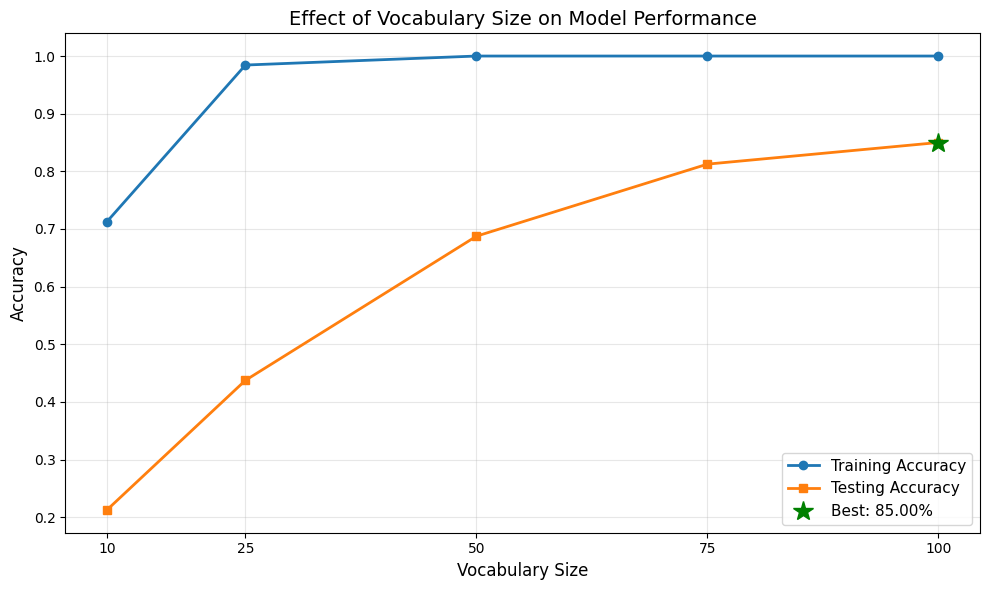


Performance Summary Table:
------------------------------------------------------------
Vocab Size   Train Acc       Test Acc       
------------------------------------------------------------
10           71.25%          21.25%         
25           98.44%          43.75%         
50           100.00%         68.75%         
75           100.00%         81.25%         
100          100.00%         85.00%         
------------------------------------------------------------


In [16]:
# Plot results
plt.figure(figsize=(10, 6))
plt.plot(results['vocab_size'], results['train_acc'], 'o-', label='Training Accuracy', linewidth=2)
plt.plot(results['vocab_size'], results['test_acc'], 's-', label='Testing Accuracy', linewidth=2)
plt.xlabel('Vocabulary Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Effect of Vocabulary Size on Model Performance', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(results['vocab_size'])

# Mark the best test accuracy
best_idx = np.argmax(results['test_acc'])
plt.plot(results['vocab_size'][best_idx], results['test_acc'][best_idx], 
         'g*', markersize=15, label=f'Best: {results["test_acc"][best_idx]:.2%}')
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Print summary table
print("\nPerformance Summary Table:")
print("-" * 60)
print(f"{'Vocab Size':<12} {'Train Acc':<15} {'Test Acc':<15}")
print("-" * 60)
for i in range(len(vocab_sizes)):
    print(f"{results['vocab_size'][i]:<12} {results['train_acc'][i]:<15.2%} {results['test_acc'][i]:<15.2%}")
print("-" * 60)

## Key Insights & Conclusions

### What We Learned:

1. **BoVW is Simple but Effective**
   - Treats images like text documents
   - Converts variable-length descriptors into fixed-size vectors
   - Works well with traditional classifiers (SVM)

2. **Vocabulary Size Trade-off**
   - Larger vocabulary = more discriminative but slower
   - Smaller vocabulary = faster but less expressive
   - Optimal size depends on dataset complexity

3. **SVM with BoVW**
   - RBF kernel captures non-linear relationships
   - Features should be normalized before SVM
   - Works better with larger vocabularies (generally)

4. **Why BoVW Works**
   - Captures local patterns (SIFT features)
   - Ignores spatial information (trade-off)
   - Robust to viewpoint changes and occlusions

### Advantages of BoVW:
✓ Simple and interpretable
✓ Combines low-level and high-level features
✓ Works with any classifier (SVM, RF, etc.)
✓ Proven effective on many datasets

### Limitations:
✗ Ignores spatial relationships
✗ Computationally expensive (SIFT extraction)
✗ Fixed vocabulary size limits expressiveness
✗ Superseded by deep learning approaches (modern)

## Bonus: Advanced Extensions

### Potential Improvements:

1. **Spatial Pyramids**
   - Divide image into spatial regions
   - Create BoVW for each region separately
   - Concatenate histograms to preserve spatial info

2. **Better Features**
   - Use ORB (faster than SIFT)
   - Extract SURF features
   - Combine multiple feature types

3. **Feature Weighting**
   - TF-IDF weighting (like NLP)
   - Weight by distance to cluster center
   - Weight by descriptor strength

4. **Hyperparameter Tuning**
   - Grid search for SVM C and gamma
   - Cross-validation for robustness
   - Test different kernels

5. **Modern Alternatives**
   - Deep learning features (VGG, ResNet)
   - Fisher Vectors
   - VLAD (Vector Locally Aggregated Descriptors)
   - Transformers and Vision Attention

## Bonus: Predict on New Images

Function to extract BoVW features and make predictions on new images

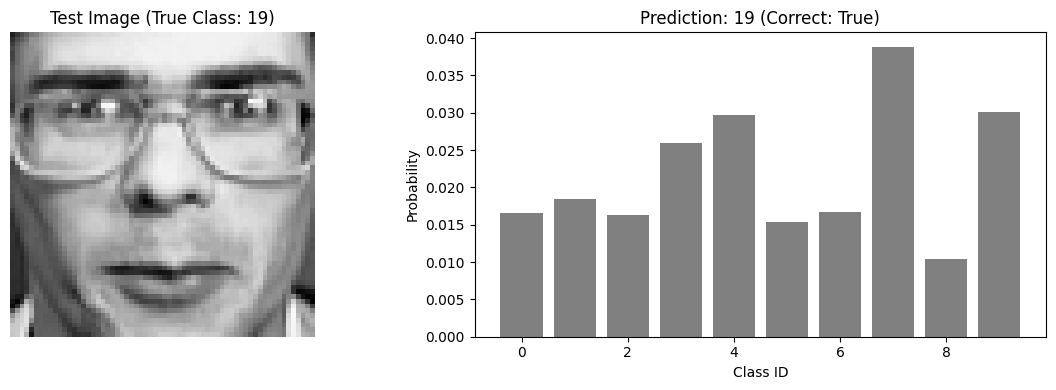

Prediction Details:
  True Label: 19
  Predicted Label: 19
  Confidence: 6.07%
  Top 3 predictions: [19 25 35]


In [17]:
def predict_on_new_image(image, sift_detector, kmeans_model, svm_model, scaler, vocab_size):
    """
    Predict class label for a new image using BoVW pipeline
    
    Args:
        image: Input image (numpy array, grayscale)
        sift_detector: SIFT detector object
        kmeans_model: Trained KMeans model
        svm_model: Trained SVM model
        scaler: Feature scaler
        vocab_size: Size of visual vocabulary
    
    Returns:
        prediction: Predicted class label
        probabilities: Probability for each class
    """
    
    # Extract SIFT features
    keypoints, descriptors = sift_detector.detectAndCompute(image, None)
    
    if descriptors is None:
        # No features found, return random prediction
        print("Warning: No features found in image")
        return -1, None
    
    # Create BoVW histogram
    cluster_assignments = kmeans_model.predict(descriptors)
    histogram, _ = np.histogram(cluster_assignments, bins=np.arange(vocab_size + 1))
    histogram = histogram.astype(float)
    histogram_norm = np.linalg.norm(histogram)
    if histogram_norm > 0:
        histogram = histogram / histogram_norm
    
    # Scale features
    histogram_scaled = scaler.transform([histogram])
    
    # Make prediction
    prediction = svm_model.predict(histogram_scaled)[0]
    probabilities = svm_model.predict_proba(histogram_scaled)[0]
    
    return prediction, probabilities


# Test prediction on a random test image
test_image_idx = np.random.choice(len(test_image_indices))
test_image = images[test_image_indices[test_image_idx]]
true_label = y_test[test_image_idx]

pred_label, pred_probs = predict_on_new_image(
    test_image, sift, kmeans, svm_model, scaler, CONFIG['vocabulary_size']
)

# Visualize prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Show image
axes[0].imshow(test_image, cmap='gray')
axes[0].set_title(f'Test Image (True Class: {true_label})')
axes[0].axis('off')

# Show class probabilities
class_ids = np.arange(len(pred_probs))
colors = ['green' if i == pred_label else 'red' if i == true_label else 'gray' 
          for i in class_ids]
axes[1].bar(class_ids[:10], pred_probs[:10], color=colors[:10])
axes[1].set_xlabel('Class ID')
axes[1].set_ylabel('Probability')
axes[1].set_title(f'Prediction: {pred_label} (Correct: {pred_label == true_label})')

plt.tight_layout()
plt.show()

print(f"Prediction Details:")
print(f"  True Label: {true_label}")
print(f"  Predicted Label: {pred_label}")
print(f"  Confidence: {pred_probs[pred_label]:.2%}")
print(f"  Top 3 predictions: {np.argsort(pred_probs)[-3:][::-1]}")

## Quick Reference: BoVW Pipeline Cheat Sheet

### Step-by-Step Summary:

```
┌─────────────────────────────────────────┐
│   TRAINING PHASE                        │
├─────────────────────────────────────────┤
│ 1. Extract SIFT descriptors             │
│    from ALL training images             │
│                                         │
│ 2. Cluster descriptors with K-Means     │
│    to create visual vocabulary          │
│                                         │
│ 3. For each image:                      │
│    - Extract SIFT                       │
│    - Assign to nearest cluster          │
│    - Create histogram of assignments    │
│    - Normalize histogram                │
│                                         │
│ 4. Train SVM on histograms              │
└─────────────────────────────────────────┘
         ↓
┌─────────────────────────────────────────┐
│   PREDICTION PHASE                      │
├─────────────────────────────────────────┤
│ 1. Extract SIFT from new image          │
│ 2. Assign to nearest clusters           │
│ 3. Create & normalize histogram         │
│ 4. Feed to trained SVM                  │
│ 5. Get class prediction                 │
└─────────────────────────────────────────┘
```

### Key Parameters:
- **Vocabulary Size (K)**: 25-100 typical, trade-off between accuracy and speed
- **SIFT Threshold**: Detect keypoints (auto in cv2)
- **SVM Kernel**: RBF works best, try linear for speed
- **SVM C**: Regularization (0.1-100), tune with grid search

### Expected Performance:
- Simple datasets: 80-95% accuracy
- Complex datasets: 40-80% accuracy
- Deep learning: Often better but requires more data

## References & Further Reading

### Papers & Concepts:
- **BoVW Original**: Csurka, G., Dance, C., Willamowski, J., Fan, L., Bray, C. (2004). "Visual Categorization with Bags of Keypoints"
- **SIFT**: Lowe, D. G. (2004). "Distinctive Image Features from Scale-Invariant Keypoints"
- **Spatial Pyramids**: Lazebnik, S., Schmid, C., Ponce, J. (2006). "Beyond Bags of Features"

### Online Resources:
- OpenCV SIFT: https://docs.opencv.org/master/da/df5/tutorial_py_sift_intro.html
- Scikit-learn SVM: https://scikit-learn.org/stable/modules/svm.html
- Computer Vision Course (Stanford CS231N): http://cs231n.stanford.edu/

### Related Methods to Explore:
- **Fisher Vectors**: Improved BoVW representation
- **VLAD**: Vector-Locally Aggregated Descriptors
- **Deep Learning**: ConvNets, ResNets, Vision Transformers
- **Metric Learning**: Learn distance metrics for features

### Caltech-101 Dataset:
- Download: http://www.vision.caltech.edu/Image_Datasets/Caltech101/
- 9,146 images, 101 object categories
- Common benchmark for testing BoVW methods